# Monte Carlo Simulations

Monte Carlo simulations sound fancy, but at their core, they are simple. They help us **estimate probabilities or outcomes by simulating random processes thousands (or even millions) of times.**

They're named after **Monte Carlo, the famous casino city**, because just like gambling, they rely on randomness and chance.

In this notebook, we'll explore how Monte Carlo simulations work with **simple examples**, and you'll see why they are so powerful!

## Why Monte Carlo?
- **Banks** use them to predict financial risks.
- **Physicists** use them to model particle collisions.
- **Engineers** use them to test designs under random conditions.

The big idea: **When exact calculations are too hard, simulations give surprisingly accurate answers.**

## Example 1: Estimating Pi
One of the classic Monte Carlo simulations is to estimate the value of π (pi) using randomness.

Estimated Pi: 3.1944


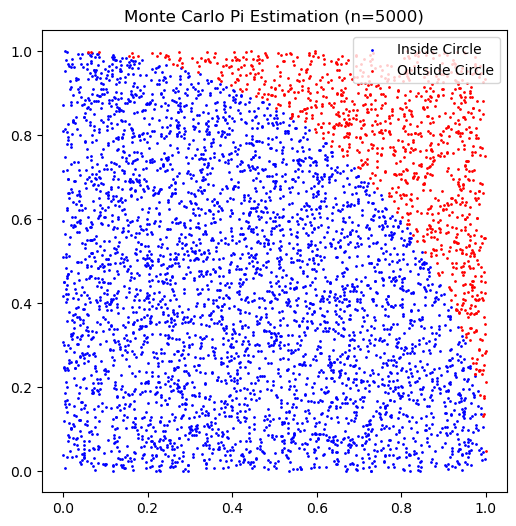

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def estimate_pi(num_points):
    inside_circle = 0
    x_in, y_in, x_out, y_out = [], [], [], []
    
    for _ in range(num_points):
        x, y = np.random.uniform(0, 1), np.random.uniform(0, 1)
        if x**2 + y**2 <= 1:
            inside_circle += 1
            x_in.append(x)
            y_in.append(y)
        else:
            x_out.append(x)
            y_out.append(y)
    pi_estimate = 4 * inside_circle / num_points
    print(f"Estimated Pi: {pi_estimate}")

    plt.figure(figsize=(6,6))
    plt.scatter(x_in, y_in, color='blue', s=1, label='Inside Circle')
    plt.scatter(x_out, y_out, color='red', s=1, label='Outside Circle')
    plt.legend()
    plt.title(f"Monte Carlo Pi Estimation (n={num_points})")
    plt.show()

estimate_pi(5000)

## Example 2: Coin Toss Probability
Let's simulate tossing a fair coin 100 times and see how often we get heads.

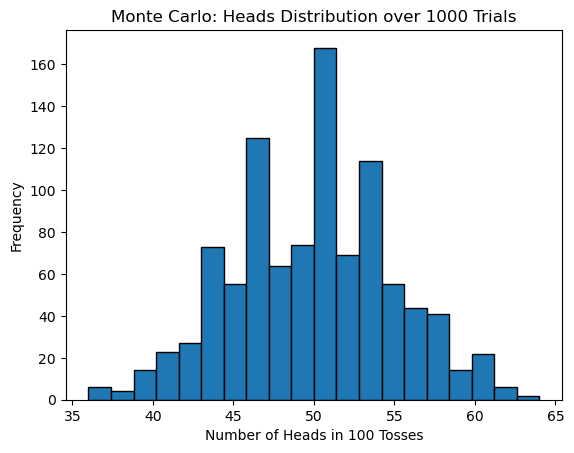

In [8]:
def simulate_coin_tosses(num_trials, num_tosses):
    heads_count = []
    for _ in range(num_trials):
        tosses = np.random.choice(['H', 'T'], size=num_tosses)
        heads = np.sum(tosses == 'H')
        heads_count.append(heads)
    return heads_count

num_trials = 1000
num_tosses = 100
heads_distribution = simulate_coin_tosses(num_trials, num_tosses)

# Plotting the results
plt.hist(heads_distribution, bins=20, edgecolor='black')
plt.title(f"Monte Carlo: Heads Distribution over {num_trials} Trials")
plt.xlabel("Number of Heads in 100 Tosses")
plt.ylabel("Frequency")
plt.show()

## Example 3: Simple Investment Simulation
Imagine you invest $1000 with a 50% chance to gain 10% and a 50% chance to lose 5% each year. We’ll simulate that investment over 10 years and repeat it 1000 times.

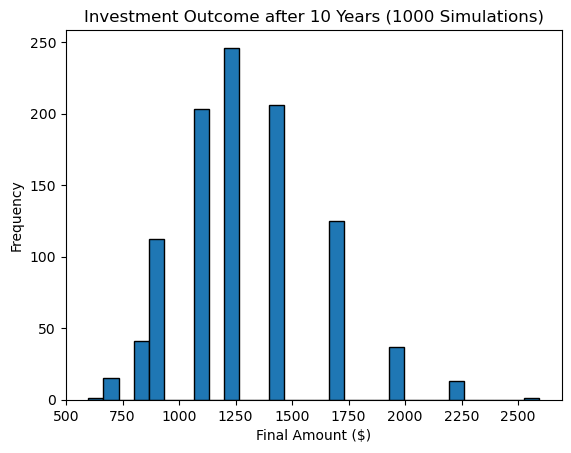

In [14]:
def simulate_investment(initial_amount, years, trials):
    final_amounts = []
    for _ in range(trials):
        amount = initial_amount
        for _ in range(years):
            if np.random.rand() < 0.5:
                amount *= 1.10
            else:
                amount *= 0.95
        final_amounts.append(amount)
    return final_amounts

trials = 1000
years = 10
initial = 1000
final_balances = simulate_investment(initial, years, trials)

plt.hist(final_balances, bins=30, edgecolor='black')
plt.title(f"Investment Outcome after {years} Years ({trials} Simulations)")
plt.xlabel("Final Amount ($)")
plt.ylabel("Frequency")
plt.show()

## Conclusion
Monte Carlo simulations are a **powerful tool** when exact calculations are too hard or impossible. By simulating randomness many times, we get a **good estimate of probabilities and outcomes**. Whether it’s estimating pi, predicting coin tosses, or modeling investments, Monte Carlo helps make sense of uncertainty through repeated trials.